# Projeto Computacional de Mecânica Clássica

## Espalhamento em Potencial Central

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from math import atan2, degrees, sqrt
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np

from utils.linear_algebra import Vec3
from utils.particle import ForceFunc, Particle, SimulationTypes

## Sistema físico

O sistema estudado é uma partícula de massa $m$ movendo-se no plano $(x,y)$ sob ação de um potencial central regularizado,

$$
V(r)=\frac{k}{\sqrt{r^2+\varepsilon^2}},
\qquad
r=\sqrt{x^2+y^2}.
$$

O parâmetro $k$ controla a intensidade e o sinal da interação. Para $k>0$, a força é repulsiva; para $k<0$, a força é atrativa. O parâmetro $\varepsilon$ evita a singularidade em $r=0$ e torna a simulação numericamente estável mesmo quando a partícula passa perto da origem.

A partícula entra pela esquerda com

$$
(x_0,y_0)=(-x_{\max}, b),
\qquad
\vec v_0=(v_0,0),
$$

onde $b$ é o parâmetro de impacto.

## Força central

Como $V$ depende apenas de $r$, a força é radial:

$$
\vec F(\vec r)=-\nabla V(r)
= -\frac{dV}{dr}\,\frac{\vec r}{r}.
$$

Para o potencial regularizado,

$$
\frac{dV}{dr}=-\frac{k r}{(r^2+\varepsilon^2)^{3/2}},
$$

e portanto

$$
\boxed{\vec F(\vec r)=\frac{k\vec r}{(r^2+\varepsilon^2)^{3/2}}}.
$$

Essa forma deixa claro o sinal: $k>0$ gera força na direção de $\vec r$, afastando a partícula da origem; $k<0$ gera força na direção oposta, atraindo a partícula para a origem.

In [2]:
K = 2.0             # [J m] intensidade padrão do potencial
EPSILON = 0.25      # [m] regularização da singularidade
MASS = 1.0          # [kg]
V0 = 2.0            # [m/s]
X_MAX = 20.0        # [m]
T_MAX = 60.0        # [s]
TIME_STEP = 0.01    # [s]


def central_potential(position: Vec3, k: float = K, epsilon: float = EPSILON) -> float:
    r_squared = position.x**2 + position.y**2 + position.z**2
    return k / sqrt(r_squared + epsilon**2)


def central_force(k: float = K, epsilon: float = EPSILON) -> ForceFunc:
    def f(particle: Particle, _: float | None = None) -> Vec3:
        r_squared = (
            particle.position.x**2
            + particle.position.y**2
            + particle.position.z**2
        )
        denominator = (r_squared + epsilon**2) ** 1.5
        return particle.position * (k / denominator)
    return f


def angular_momentum_z(particle: Particle) -> float:
    return particle.mass * particle.position.cross(particle.velocity).z


def scattering_mechanical_energy(
    particle: Particle,
    k: float = K,
    epsilon: float = EPSILON,
) -> float:
    return particle.kinetic_energy() + central_potential(particle.position, k, epsilon)

## Simulação

A simulação usa diretamente a classe `Particle`. Neste problema, o centro de força é fixo na origem: ele define um campo externo, mas não possui posição, velocidade ou massa dinâmica na simulação. Portanto, não há uma segunda partícula que precise receber a força oposta, e usar `ParticleSystem` seria uma abstração desnecessária para este enunciado. A classe `ParticleSystem` fica reservada para problemas em que duas ou mais partículas evoluem simultaneamente e as interações de par precisam ser calculadas no mesmo estado global.

O Ângulo de espalhamento é medido a partir da velocidade final:

$$
\theta=\operatorname{atan2}(v_{y,f},v_{x,f}),
$$

pois a velocidade inicial aponta na direção $+x$.

In [3]:
@dataclass
class ScatteringMetrics:
    impact_parameter: float
    theta_rad: float
    theta_deg: float
    speed_initial: float
    speed_final: float
    energy_initial: float
    energy_final: float
    angular_momentum_initial: float
    angular_momentum_final: float
    relative_energy_error: float
    relative_angular_momentum_error: float
    max_relative_energy_error: float
    max_relative_angular_momentum_error: float
    min_radius: float
    escaped: bool


@dataclass
class ScatteringResults:
    times: np.ndarray
    positions: np.ndarray
    velocities: np.ndarray
    energies: np.ndarray
    angular_momenta: np.ndarray
    metrics: ScatteringMetrics


def relative_error(values: np.ndarray, reference: float) -> np.ndarray:
    denominator = max(abs(reference), 1e-12)
    return np.abs(values - reference) / denominator


def extract_scattering_metrics(
    times: np.ndarray,
    positions: np.ndarray,
    velocities: np.ndarray,
    energies: np.ndarray,
    angular_momenta: np.ndarray,
    impact_parameter: float,
    escaped: bool,
) -> ScatteringMetrics:
    initial_velocity = velocities[0]
    final_velocity = velocities[-1]

    theta_rad = float(atan2(final_velocity[1], final_velocity[0]))
    theta_deg = degrees(theta_rad)

    radii = np.linalg.norm(positions[:, :2], axis=1)
    energy_errors = relative_error(energies, float(energies[0]))
    angular_errors = relative_error(angular_momenta, float(angular_momenta[0]))

    return ScatteringMetrics(
        impact_parameter=impact_parameter,
        theta_rad=theta_rad,
        theta_deg=theta_deg,
        speed_initial=float(np.linalg.norm(initial_velocity)),
        speed_final=float(np.linalg.norm(final_velocity)),
        energy_initial=float(energies[0]),
        energy_final=float(energies[-1]),
        angular_momentum_initial=float(angular_momenta[0]),
        angular_momentum_final=float(angular_momenta[-1]),
        relative_energy_error=float(energy_errors[-1]),
        relative_angular_momentum_error=float(angular_errors[-1]),
        max_relative_energy_error=float(np.max(energy_errors)),
        max_relative_angular_momentum_error=float(np.max(angular_errors)),
        min_radius=float(np.min(radii)),
        escaped=escaped,
    )


def simulate_scattering(
    impact_parameter: float = 1.5,
    mass: float = MASS,
    k: float = K,
    epsilon: float = EPSILON,
    v0: float = V0,
    x_max: float = X_MAX,
    t_max: float = T_MAX,
    dt: float = TIME_STEP,
    simulation_type: SimulationTypes = "RK4",
) -> ScatteringResults:
    particle = Particle(
        mass=mass,
        position=Vec3(-x_max, impact_parameter, 0.0),
        velocity=Vec3(v0, 0.0, 0.0),
        simulation_type=simulation_type,
    )
    forces = [central_force(k=k, epsilon=epsilon)]

    n_steps = int(t_max / dt) + 1
    times = np.empty(n_steps, dtype=np.float64)
    positions = np.empty((n_steps, 3), dtype=np.float64)
    velocities = np.empty((n_steps, 3), dtype=np.float64)
    energies = np.empty(n_steps, dtype=np.float64)
    angular_momenta = np.empty(n_steps, dtype=np.float64)

    def save_state(i: int, t: float) -> None:
        p = particle
        times[i] = t
        positions[i, 0] = p.position.x
        positions[i, 1] = p.position.y
        positions[i, 2] = p.position.z
        velocities[i, 0] = p.velocity.x
        velocities[i, 1] = p.velocity.y
        velocities[i, 2] = p.velocity.z
        energies[i] = scattering_mechanical_energy(p, k, epsilon)
        angular_momenta[i] = angular_momentum_z(p)

    t = 0.0
    saved_steps = 0
    escaped = False

    for i in range(n_steps):
        save_state(i, t)
        saved_steps = i + 1

        p = particle
        if t > 0.0 and p.position.x >= x_max and p.velocity.x > 0.0:
            escaped = True
            break

        particle.update(forces=forces, dt=dt, time=t)
        t += dt

    times_s = times[:saved_steps]
    positions_s = positions[:saved_steps]
    velocities_s = velocities[:saved_steps]
    energies_s = energies[:saved_steps]
    angular_momenta_s = angular_momenta[:saved_steps]

    return ScatteringResults(
        times=times_s,
        positions=positions_s,
        velocities=velocities_s,
        energies=energies_s,
        angular_momenta=angular_momenta_s,
        metrics=extract_scattering_metrics(
            times_s,
            positions_s,
            velocities_s,
            energies_s,
            angular_momenta_s,
            impact_parameter=impact_parameter,
            escaped=escaped,
        ),
    )

## Plotagem e utilidades

In [4]:
@dataclass
class ScatteringPlot:
    label: str
    result: ScatteringResults
    plot_style: dict[str, Any] | None = None


def export_figure(
    fig: plt.Figure,
    filename_stem: str,
    formats: tuple[str, ...] = ("pdf",),
    output_dir: str = "outputs/figures",
) -> list[str]:
    folder = Path(output_dir)
    folder.mkdir(parents=True, exist_ok=True)
    exported_paths: list[str] = []
    for ext in formats:
        ext_clean = ext.lower().lstrip(".")
        file_path = folder / f"{filename_stem}.{ext_clean}"
        fig.savefig(file_path, format=ext_clean, bbox_inches="tight")
        exported_paths.append(str(file_path))
    return exported_paths


def plot_xy_trajectories(
    simulations: list[ScatteringPlot],
    ax: plt.Axes | None = None,
    title: str = "Trajetória no plano $(x,y)$",
    show_legend: bool = True,
) -> tuple[plt.Figure, plt.Axes]:
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    else:
        fig = ax.figure

    for sim in simulations:
        style = sim.plot_style or {}
        positions = sim.result.positions
        ax.plot(positions[:, 0], positions[:, 1], label=sim.label, **style)

    ax.scatter([0.0], [0.0], color="black", s=35, marker="x", label="centro")
    ax.axhline(0.0, color="black", linewidth=0.5, alpha=0.35)
    ax.axvline(0.0, color="black", linewidth=0.5, alpha=0.35)
    ax.set_xlabel(r"$x\,(m)$")
    ax.set_ylabel(r"$y\,(m)$")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="datalim")
    ax.grid(True, alpha=0.3)
    if show_legend:
        ax.legend(fontsize=8)
    return fig, ax


def plot_speed_per_time(
    simulations: list[ScatteringPlot],
    ax: plt.Axes | None = None,
    show_legend: bool = True,
) -> tuple[plt.Figure, plt.Axes]:
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    else:
        fig = ax.figure

    for sim in simulations:
        style = sim.plot_style or {}
        speeds = np.linalg.norm(sim.result.velocities, axis=1)
        ax.plot(sim.result.times, speeds, label=sim.label, **style)

    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel(r"$|\vec v|\,(m/s)$")
    ax.set_title("Velocidade ao longo do tempo")
    ax.grid(True, alpha=0.3)
    if show_legend:
        ax.legend(fontsize=8)
    return fig, ax


def plot_conservation_errors(
    simulations: list[ScatteringPlot],
    axes: np.ndarray | None = None,
    show_legend: bool = True,
) -> tuple[plt.Figure, np.ndarray]:
    if axes is None:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    else:
        fig = axes[0].figure

    for sim in simulations:
        style = sim.plot_style or {}
        result = sim.result
        e_err = np.maximum(relative_error(result.energies, result.energies[0]), 1e-16)
        l_err = np.maximum(relative_error(result.angular_momenta, result.angular_momenta[0]), 1e-16)
        axes[0].semilogy(result.times, e_err, label=sim.label, **style)
        axes[1].semilogy(result.times, l_err, label=sim.label, **style)

    axes[0].set_xlabel("Tempo (s)")
    axes[0].set_ylabel(r"$|E(t)-E_0|/|E_0|$")
    axes[0].set_title("Erro relativo da energia")
    axes[0].grid(True, alpha=0.3)

    axes[1].set_xlabel("Tempo (s)")
    axes[1].set_ylabel(r"$|L(t)-L_0|/|L_0|$")
    axes[1].set_title("Erro relativo do momento angular")
    axes[1].grid(True, alpha=0.3)

    if show_legend:
        for ax in axes:
            ax.legend(fontsize=8)
    return fig, axes


def plot_scattering_panels(
    simulations: list[ScatteringPlot],
    suptitle: str | None = None,
    figsize: tuple[float, float] = (13, 9),
) -> tuple[plt.Figure, np.ndarray]:
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    plot_xy_trajectories(simulations, ax=axes[0, 0], show_legend=False)
    plot_speed_per_time(simulations, ax=axes[0, 1], show_legend=False)
    plot_conservation_errors(simulations, axes=axes[1, :], show_legend=False)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.01), ncol=min(len(handles), 4), fontsize=8)

    if suptitle is not None:
        fig.suptitle(suptitle, fontsize=12)
    fig.tight_layout()
    plt.show()
    return fig, axes


def plot_theta_vs_b(
    datasets: list[tuple[str, np.ndarray, list[ScatteringResults], dict[str, Any] | None]],
    ax: plt.Axes | None = None,
    title: str = r"Ângulo de espalhamento $\theta(b)$",
) -> tuple[plt.Figure, plt.Axes]:
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    for label, b_values, results, style in datasets:
        theta_values = [result.metrics.theta_deg for result in results]
        ax.plot(b_values, theta_values, marker="o", markersize=3.5, label=label, **(style or {}))

    ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_xlabel(r"$b\,(m)$")
    ax.set_ylabel(r"$\theta\,(graus)$")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    return fig, ax


def print_scattering_metrics(metrics: ScatteringMetrics) -> None:
    print(f"b = {metrics.impact_parameter:.3f} m")
    print(f"theta = {metrics.theta_deg:.4f} graus")
    print(f"|v_i| = {metrics.speed_initial:.6f} m/s")
    print(f"|v_f| = {metrics.speed_final:.6f} m/s")
    print(f"E_i = {metrics.energy_initial:.8f} J")
    print(f"E_f = {metrics.energy_final:.8f} J")
    print(f"erro relativo final de E = {metrics.relative_energy_error:.3e}")
    print(f"erro relativo maximo de E = {metrics.max_relative_energy_error:.3e}")
    print(f"L_i = {metrics.angular_momentum_initial:.8f} kg m^2/s")
    print(f"L_f = {metrics.angular_momentum_final:.8f} kg m^2/s")
    print(f"erro relativo final de L = {metrics.relative_angular_momentum_error:.3e}")
    print(f"erro relativo maximo de L = {metrics.max_relative_angular_momentum_error:.3e}")
    print(f"r_min = {metrics.min_radius:.6f} m")
    print(f"escapou pelo lado direito: {metrics.escaped}")


def print_scattering_table(results: list[ScatteringResults]) -> None:
    print("b (m)   theta (graus)   r_min (m)   erro max E     erro max L   escapou")
    for result in results:
        metrics = result.metrics
        print(
            f"{metrics.impact_parameter:5.2f}"
            f" {metrics.theta_deg:14.4f}"
            f" {metrics.min_radius:10.4f}"
            f" {metrics.max_relative_energy_error:12.3e}"
            f" {metrics.max_relative_angular_momentum_error:12.3e}"
            f" {str(metrics.escaped):>8}"
        )

## Questões

### Questão 1

As equações de movimento são

$$
\frac{dx}{dt}=v_x,
\qquad
\frac{dy}{dt}=v_y,
$$

$$
\frac{dv_x}{dt}=\frac{1}{m}\frac{kx}{(x^2+y^2+\varepsilon^2)^{3/2}},
\qquad
\frac{dv_y}{dt}=\frac{1}{m}\frac{ky}{(x^2+y^2+\varepsilon^2)^{3/2}}.
$$

No método de Euler explícito, avaliando tudo no instante $t_n$, temos

$$
x_{n+1}=x_n+v_{x,n}\Delta t,
\qquad
y_{n+1}=y_n+v_{y,n}\Delta t,
$$

$$
v_{x,n+1}=v_{x,n}+\frac{kx_n}{m(x_n^2+y_n^2+\varepsilon^2)^{3/2}}\Delta t,
$$

$$
v_{y,n+1}=v_{y,n}+\frac{ky_n}{m(x_n^2+y_n^2+\varepsilon^2)^{3/2}}\Delta t.
$$

Na implementação numérica abaixo, o método padrão usado nos gráficos é RK4, pois ele conserva melhor energia e momento angular. O modo `Euler` também está disponível para comparação.

### Questão 2

A implementação numérica integra o sistema até a partícula escapar para $x\geq x_{\max}$ com $v_x>0$, isto é, até sair da região de interação pelo lado direito. A condição inicial padrão usada nesta primeira simulação é

$$
(x_0,y_0)=(-12,1.5),
\qquad
\vec v_0=(2,0),
\qquad
m=1,
\qquad
k=2,
\qquad
\varepsilon=0.25.
$$

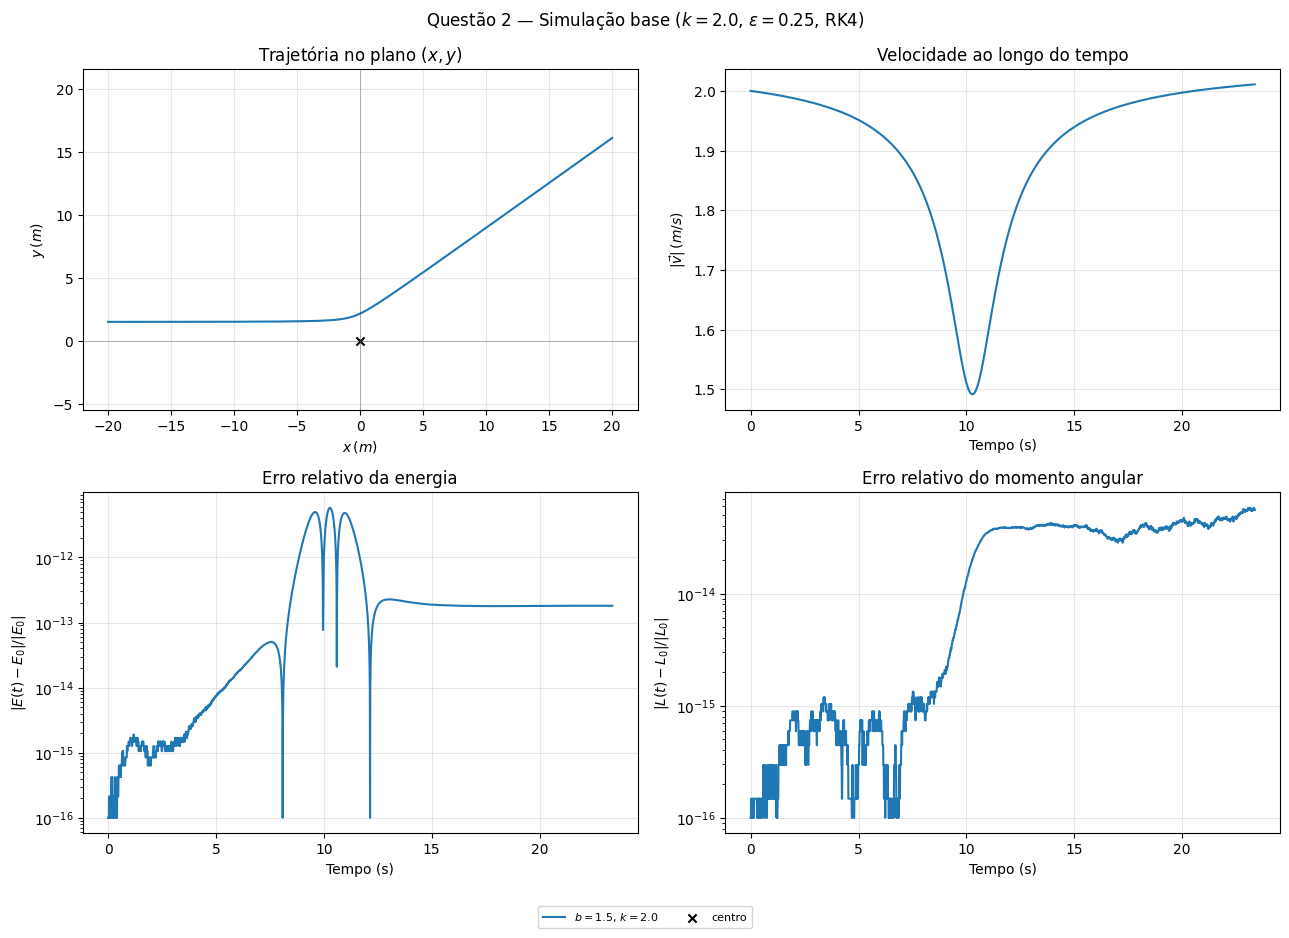

b = 1.500 m
theta = 35.4889 graus
|v_i| = 2.000000 m/s
|v_f| = 2.010889 m/s
E_i = 2.09971218 J
E_f = 2.09971218 J
erro relativo final de E = 1.808e-13
erro relativo maximo de E = 5.768e-12
L_i = -3.00000000 kg m^2/s
L_f = -3.00000000 kg m^2/s
erro relativo final de L = 5.566e-14
erro relativo maximo de L = 5.803e-14
r_min = 2.010967 m
escapou pelo lado direito: True


In [5]:
result_q2 = simulate_scattering(
    impact_parameter=1.5,
    k=K,
    epsilon=EPSILON,
    simulation_type="RK4",
)

fig_q2, axes_q2 = plot_scattering_panels(
    [ScatteringPlot(label=rf"$b=1.5$, $k={K}$", result=result_q2)],
    suptitle=rf"Questão 2 — Simulação base ($k={K}$, $\varepsilon={EPSILON}$, RK4)",
)
export_figure(fig_q2, "questao2_simulacao_base")
print_scattering_metrics(result_q2.metrics)

A trajetória não permanece retilínea: ao se aproximar da origem, a partícula sente a força central e sua direção assintótica muda. Para $k>0$, a força é repulsiva, então a partícula passa acima do centro e é desviada para valores ainda maiores de $y$. Como o potencial é conservativo e central, a energia mecânica e o momento angular devem permanecer constantes; as pequenas variações observadas nos gráficos são erros de integração numérica.

### Questão 3

Para estudar o papel do parâmetro de impacto, mantemos $m$, $v_0$, $k$ e $\varepsilon$ fixos e variamos apenas $b$. Valores menores de $b$ fazem a partícula passar mais perto da origem, onde a força é mais intensa; valores maiores de $b$ produzem trajetórias quase retilíneas.

b (m)   theta (graus)   r_min (m)   erro max E     erro max L   escapou
 0.70        68.0459     1.2954    3.547e-11    4.856e-13     True
 1.00        50.9581     1.5535    1.617e-11    2.061e-13     True
 1.50        35.4889     2.0110    5.768e-12    5.803e-14     True
 2.20        24.6847     2.6733    1.882e-12    6.863e-15     True
 3.30        16.5489     3.7318    4.469e-13    5.652e-15     True
 5.00        10.8182     5.3825    8.407e-14    4.263e-15     True


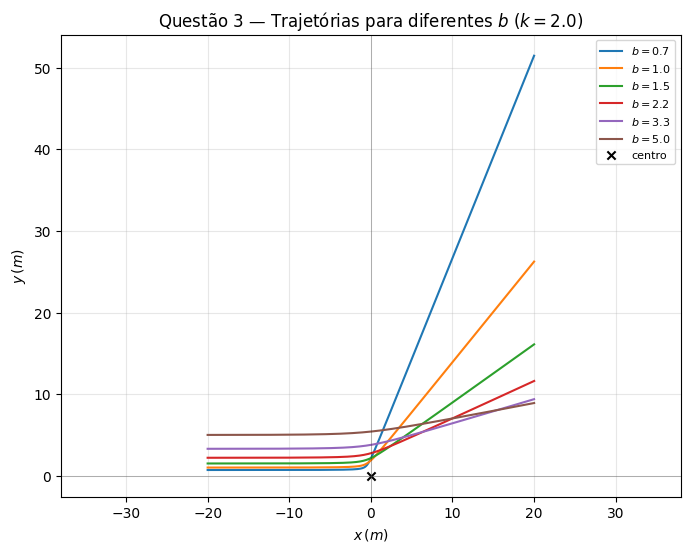

In [6]:
b_values_q3 = np.array([0.7, 1.0, 1.5, 2.2, 3.3, 5.0], dtype=float)
results_q3 = [
    simulate_scattering(impact_parameter=float(b), k=K, epsilon=EPSILON)
    for b in b_values_q3
]

plots_q3 = [
    ScatteringPlot(label=rf"$b={b:.1f}$", result=result)
    for b, result in zip(b_values_q3, results_q3, strict=True)
]

fig_q3, ax_q3 = plot_xy_trajectories(
    plots_q3,
    title=rf"Questão 3 — Trajetórias para diferentes $b$ ($k={K}$)",
)
export_figure(fig_q3, "questao3_trajetorias_b")
print_scattering_table(results_q3)

A dependência qualitativa é a esperada para espalhamento central: quanto menor é $b$, menor é a distância mínima ao centro e maior é o desvio. Para $b$ grande, a partícula interage apenas com a cauda fraca do potencial e o Ângulo final se aproxima de zero.

### Questão 4

A energia mecânica e o momento angular no eixo $z$ são

$$
E=\frac{1}{2}m(v_x^2+v_y^2)+\frac{k}{\sqrt{x^2+y^2+\varepsilon^2}},
$$

$$
L_z=m(xv_y-yv_x).
$$

Como a força é conservativa e central, $E$ e $L_z$ devem ser constantes. A comparação abaixo usa a mesma condição inicial com Euler e RK4.

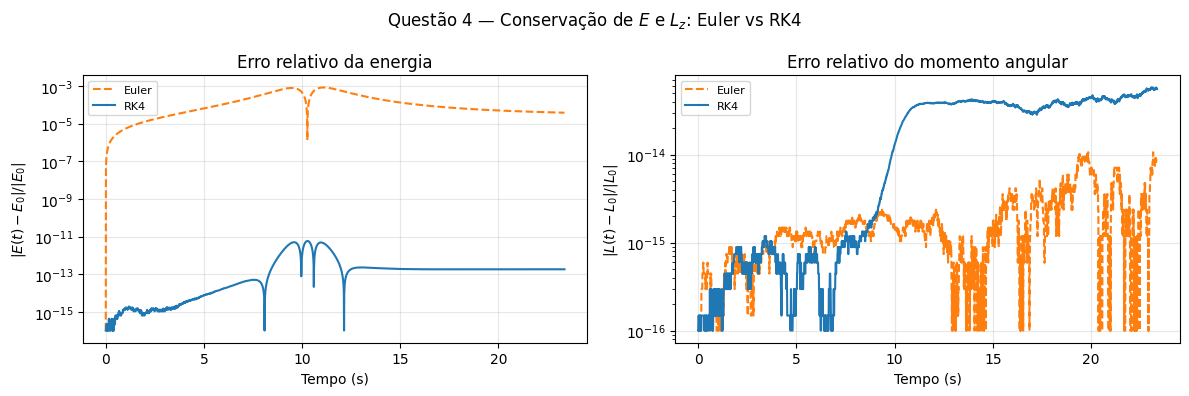

Euler
b = 1.500 m
theta = 35.4894 graus
|v_i| = 2.000000 m/s
|v_f| = 2.010848 m/s
E_i = 2.09971218 J
E_f = 2.09963219 J
erro relativo final de E = 3.810e-05
erro relativo maximo de E = 8.344e-04
L_i = -3.00000000 kg m^2/s
L_f = -3.00000000 kg m^2/s
erro relativo final de L = 8.290e-15
erro relativo maximo de L = 1.066e-14
r_min = 2.010995 m
escapou pelo lado direito: True

RK4
b = 1.500 m
theta = 35.4889 graus
|v_i| = 2.000000 m/s
|v_f| = 2.010889 m/s
E_i = 2.09971218 J
E_f = 2.09971218 J
erro relativo final de E = 1.808e-13
erro relativo maximo de E = 5.768e-12
L_i = -3.00000000 kg m^2/s
L_f = -3.00000000 kg m^2/s
erro relativo final de L = 5.566e-14
erro relativo maximo de L = 5.803e-14
r_min = 2.010967 m
escapou pelo lado direito: True


In [7]:
result_q4_euler = simulate_scattering(
    impact_parameter=1.5,
    k=K,
    epsilon=EPSILON,
    simulation_type="Euler",
)
result_q4_rk4 = simulate_scattering(
    impact_parameter=1.5,
    k=K,
    epsilon=EPSILON,
    simulation_type="RK4",
)

fig_q4, axes_q4 = plot_conservation_errors(
    [
        ScatteringPlot(label="Euler", result=result_q4_euler, plot_style={"linestyle": "--", "color": "C1"}),
        ScatteringPlot(label="RK4", result=result_q4_rk4, plot_style={"linestyle": "-", "color": "C0"}),
    ]
)
fig_q4.suptitle(r"Questão 4 — Conservação de $E$ e $L_z$: Euler vs RK4", fontsize=12)
fig_q4.tight_layout()
plt.show()
export_figure(fig_q4, "questao4_conservacao_euler_rk4")

print("Euler")
print_scattering_metrics(result_q4_euler.metrics)
print()
print("RK4")
print_scattering_metrics(result_q4_rk4.metrics)

O RK4 apresenta erros relativos muito menores que o Euler para o mesmo passo temporal. O erro não representa uma falha da conservação física: ele vem da discretização temporal. O momento angular é especialmente sensível a erros de simetria numérica, pois depende simultaneamente de posição e velocidade.

### Questão 5

O Ângulo de espalhamento é calculado pela direção da velocidade final. Para $b>0$ e $k>0$, o desvio é positivo: a partícula é repelida para cima. A varredura abaixo mostra $\theta(b)$.

b (m)   theta (graus)   r_min (m)   erro max E     erro max L   escapou
 0.70        68.0459     1.2954    3.547e-11    4.856e-13     True
 2.07        26.1300     2.5532    2.276e-12    1.113e-14     True
 3.45        15.8343     3.8752    3.777e-13    4.636e-15     True
 6.00         8.9217     6.3574    3.687e-14    3.553e-15     True


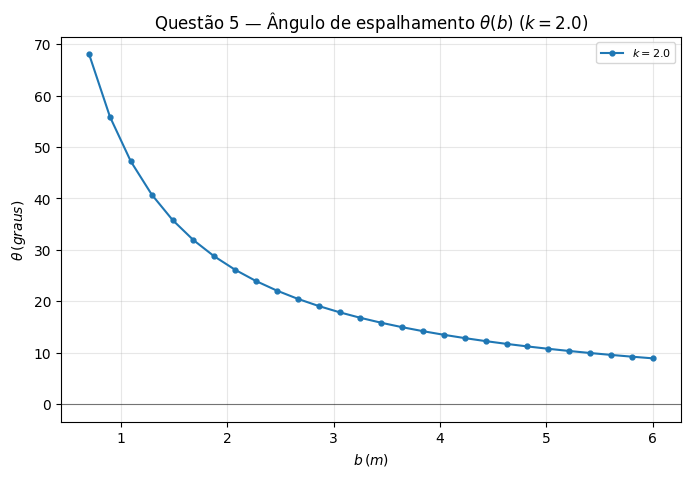

In [8]:
b_values_q5 = np.linspace(0.7, 6.0, 28)
results_q5 = [
    simulate_scattering(impact_parameter=float(b), k=K, epsilon=EPSILON)
    for b in b_values_q5
]

fig_q5, ax_q5 = plot_theta_vs_b(
    [(rf"$k={K}$", b_values_q5, results_q5, {"color": "C0"})],
    title=rf"Questão 5 — Ângulo de espalhamento $\theta(b)$ ($k={K}$)",
)
export_figure(fig_q5, "questao5_theta_b")
print_scattering_table([results_q5[0], results_q5[7], results_q5[14], results_q5[-1]])

O gráfico mostra que $\theta$ diminui com $b$. Fisicamente, isso ocorre porque a intensidade efetiva da interação durante a passagem depende da proximidade ao centro. Em colisões rasantes, com $b$ grande, a força acumulada quase não altera a direção da velocidade.

### Questão 6

Agora comparamos interações fracas e fortes. A única alteração é o módulo de $k$; os demais parâmetros são mantidos fixos. Uma interação mais forte produz maior deflexão para o mesmo parâmetro de impacto.

Interação fraca
b = 1.500 m
theta = 12.8823 graus
|v_i| = 2.000000 m/s
|v_f| = 2.000718 m/s
E_i = 2.03489926 J
E_f = 2.03489926 J
erro relativo final de E = 1.115e-13
erro relativo maximo de E = 9.034e-12
L_i = -3.00000000 kg m^2/s
L_f = -3.00000000 kg m^2/s
erro relativo final de L = 2.191e-14
erro relativo maximo de L = 2.428e-14
r_min = 1.666875 m
escapou pelo lado direito: True

Interação forte
b = 1.500 m
theta = 50.9255 graus
|v_i| = 2.000000 m/s
|v_f| = 2.029915 m/s
E_i = 2.14956828 J
E_f = 2.14956828 J
erro relativo final de E = 1.289e-13
erro relativo maximo de E = 3.688e-12
L_i = -3.00000000 kg m^2/s
L_f = -3.00000000 kg m^2/s
erro relativo final de L = 1.184e-15
erro relativo maximo de L = 2.783e-14
r_min = 2.298309 m
escapou pelo lado direito: True


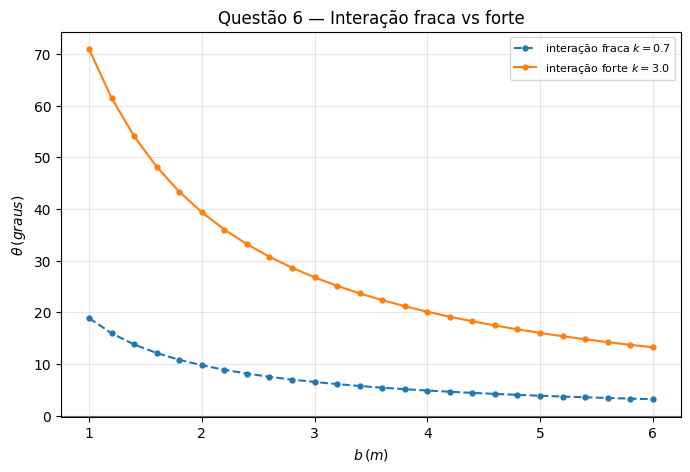

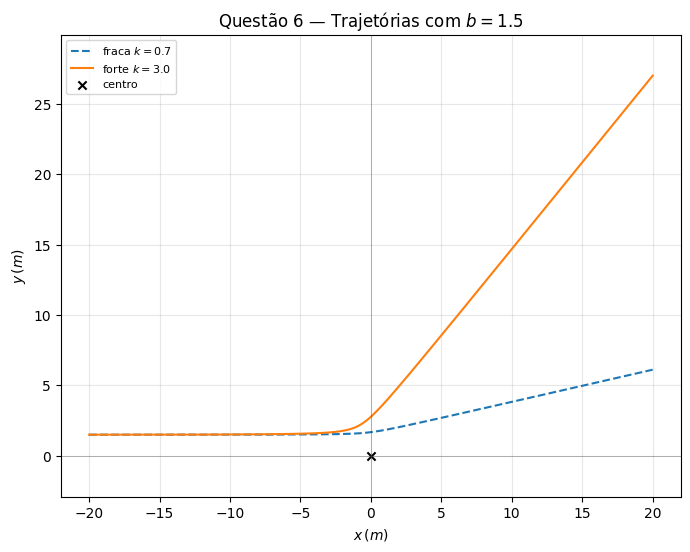

In [9]:
k_weak = 0.7
k_strong = 3.0
b_values_q6 = np.linspace(1.0, 6.0, 26)

results_q6_weak = [
    simulate_scattering(impact_parameter=float(b), k=k_weak, epsilon=EPSILON)
    for b in b_values_q6
]
results_q6_strong = [
    simulate_scattering(impact_parameter=float(b), k=k_strong, epsilon=EPSILON)
    for b in b_values_q6
]

fig_q6_theta, ax_q6_theta = plot_theta_vs_b(
    [
        (rf"interação fraca $k={k_weak}$", b_values_q6, results_q6_weak, {"color": "C0", "linestyle": "--"}),
        (rf"interação forte $k={k_strong}$", b_values_q6, results_q6_strong, {"color": "C1", "linestyle": "-"}),
    ],
    title="Questão 6 — Interação fraca vs forte",
)
export_figure(fig_q6_theta, "questao6_theta_interacao_fraca_forte")

results_q6_traj = [
    simulate_scattering(impact_parameter=1.5, k=k_weak, epsilon=EPSILON),
    simulate_scattering(impact_parameter=1.5, k=k_strong, epsilon=EPSILON),
]
fig_q6_traj, ax_q6_traj = plot_xy_trajectories(
    [
        ScatteringPlot(label=rf"fraca $k={k_weak}$", result=results_q6_traj[0], plot_style={"linestyle": "--", "color": "C0"}),
        ScatteringPlot(label=rf"forte $k={k_strong}$", result=results_q6_traj[1], plot_style={"linestyle": "-", "color": "C1"}),
    ],
    title=r"Questão 6 — Trajetórias com $b=1.5$",
)
export_figure(fig_q6_traj, "questao6_trajetorias_interacao_fraca_forte")

print("Interação fraca")
print_scattering_metrics(results_q6_traj[0].metrics)
print()
print("Interação forte")
print_scattering_metrics(results_q6_traj[1].metrics)

A interação forte tem maior força radial durante toda a passagem, logo transfere mais momento transversal à partícula. Por isso, para o mesmo $b$, o Ângulo de espalhamento é maior. A diferença é mais visível para impactos próximos, pois a partícula entra na região em que o gradiente do potencial é mais intenso.

### Questão 7

A comparação entre $k>0$ e $k<0$ separa os casos repulsivo e atrativo. Mantemos $|k|$ fixo para isolar apenas o efeito do sinal.

Repulsiva
b = 1.500 m
theta = 35.4889 graus
|v_i| = 2.000000 m/s
|v_f| = 2.010889 m/s
E_i = 2.09971218 J
E_f = 2.09971218 J
erro relativo final de E = 1.808e-13
erro relativo maximo de E = 5.768e-12
L_i = -3.00000000 kg m^2/s
L_f = -3.00000000 kg m^2/s
erro relativo final de L = 5.566e-14
erro relativo maximo de L = 5.803e-14
r_min = 2.010967 m
escapou pelo lado direito: True

Atrativa
b = 1.500 m
theta = -35.7118 graus
|v_i| = 2.000000 m/s
|v_f| = 1.992500 m/s
E_i = 1.90028782 J
E_f = 1.90028782 J
erro relativo final de E = 4.120e-11
erro relativo maximo de E = 7.883e-10
L_i = -3.00000000 kg m^2/s
L_f = -3.00000000 kg m^2/s
erro relativo final de L = 5.901e-12
erro relativo maximo de L = 5.928e-12
r_min = 1.108867 m
escapou pelo lado direito: True


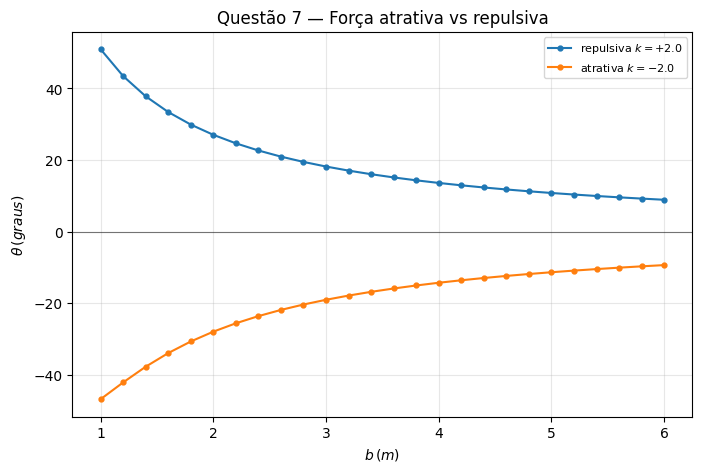

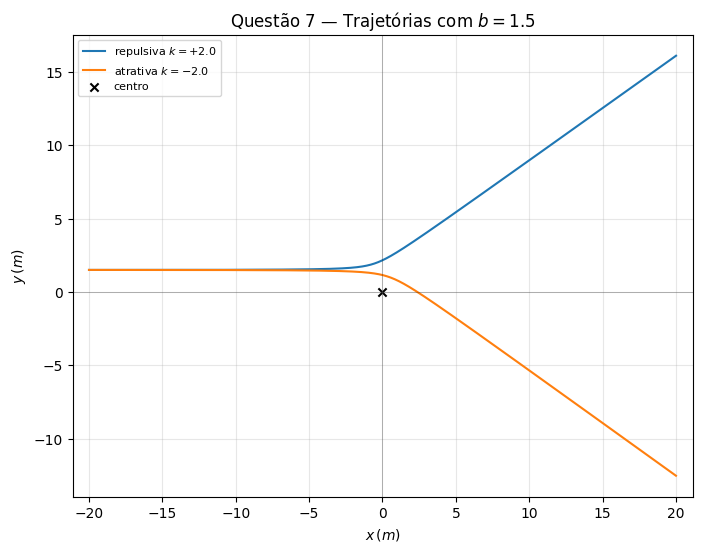

In [10]:
k_abs_q7 = 2.0
b_values_q7 = np.linspace(1.0, 6.0, 26)

results_q7_repulsive = [
    simulate_scattering(impact_parameter=float(b), k=+k_abs_q7, epsilon=EPSILON)
    for b in b_values_q7
]
results_q7_attractive = [
    simulate_scattering(impact_parameter=float(b), k=-k_abs_q7, epsilon=EPSILON)
    for b in b_values_q7
]

fig_q7_theta, ax_q7_theta = plot_theta_vs_b(
    [
        (rf"repulsiva $k=+{k_abs_q7}$", b_values_q7, results_q7_repulsive, {"color": "C0"}),
        (rf"atrativa $k=-{k_abs_q7}$", b_values_q7, results_q7_attractive, {"color": "C1"}),
    ],
    title="Questão 7 — Força atrativa vs repulsiva",
)
export_figure(fig_q7_theta, "questao7_theta_atrativa_repulsiva")

results_q7_traj = [
    simulate_scattering(impact_parameter=1.5, k=+k_abs_q7, epsilon=EPSILON),
    simulate_scattering(impact_parameter=1.5, k=-k_abs_q7, epsilon=EPSILON),
]
fig_q7_traj, ax_q7_traj = plot_xy_trajectories(
    [
        ScatteringPlot(label=rf"repulsiva $k=+{k_abs_q7}$", result=results_q7_traj[0], plot_style={"color": "C0"}),
        ScatteringPlot(label=rf"atrativa $k=-{k_abs_q7}$", result=results_q7_traj[1], plot_style={"color": "C1"}),
    ],
    title=r"Questão 7 — Trajetórias com $b=1.5$",
)
export_figure(fig_q7_traj, "questao7_trajetorias_atrativa_repulsiva")

print("Repulsiva")
print_scattering_metrics(results_q7_traj[0].metrics)
print()
print("Atrativa")
print_scattering_metrics(results_q7_traj[1].metrics)

Na força repulsiva, a trajetória se afasta do centro e o Ângulo tem sinal positivo para $b>0$. Na força atrativa, a partícula é puxada em direção ao centro, passa por uma região de maior curvatura e sai com Ângulo de sinal oposto. Em ambos os casos, o módulo do desvio diminui quando $b$ aumenta.

### Questão 8 (opcional)

O parâmetro $\varepsilon$ suaviza o potencial perto da origem. Valores menores deixam a interação mais próxima de $1/r$ e tornam a força mais intensa em passagens próximas; valores maiores espalham a interação por uma região mais larga e reduzem a deflexão máxima.

b (m)   theta (graus)   r_min (m)   erro max E     erro max L   escapou
 0.80        62.6717     1.3903    2.929e-11    4.099e-13     True
 0.80        62.2145     1.3865    2.857e-11    3.367e-13     True
 0.80        59.1008     1.3615    2.415e-11    4.299e-13     True
 0.80        42.2041     1.2340    9.676e-12    1.382e-13     True


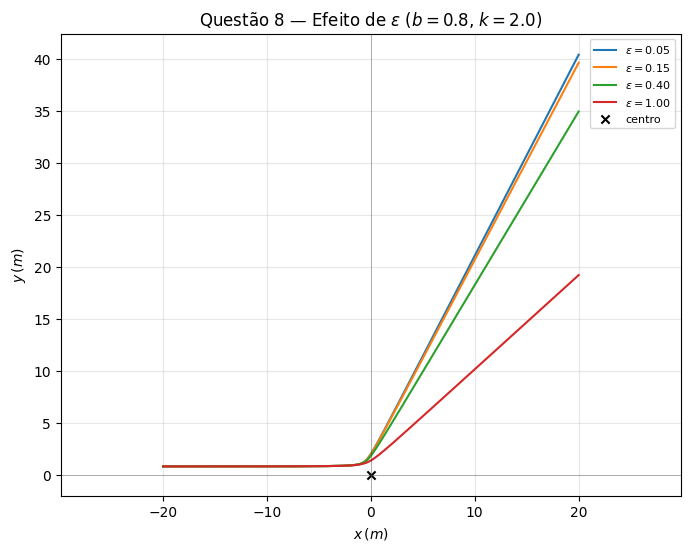

In [11]:
epsilon_values_q8 = np.array([0.05, 0.15, 0.40, 1.00], dtype=float)
results_q8 = [
    simulate_scattering(impact_parameter=0.8, k=K, epsilon=float(eps))
    for eps in epsilon_values_q8
]

fig_q8, ax_q8 = plot_xy_trajectories(
    [
        ScatteringPlot(label=rf"$\varepsilon={eps:.2f}$", result=result)
        for eps, result in zip(epsilon_values_q8, results_q8, strict=True)
    ],
    title=rf"Questão 8 — Efeito de $\varepsilon$ ($b=0.8$, $k={K}$)",
)
export_figure(fig_q8, "questao8_variacao_epsilon")
print_scattering_table(results_q8)

Para o caso regularizado, $\varepsilon$ funciona como uma escala de suavização. Quando $\varepsilon$ aumenta, a força máxima próxima da origem fica menor e a trajetória se aproxima mais de uma passagem suave. Quando $\varepsilon$ diminui, a dinâmica perto da origem se torna mais brusca e exige passos temporais menores para manter boa conservação de energia e momento angular.